In [ ]:
!pip install uncertainty-toolbox
!pip install gpytorch==1.5.1
!pip install netcal
# !pip install --upgrade torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.1/503.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import uncertainty_toolbox as uct

In [ ]:
!unzip dataset.zip

Archive:  dataset.zip
   creating: dataset/
  inflating: dataset/predictions_and_targets_DE1.npz  
  inflating: dataset/predictions_and_targets_DE2.npz  
  inflating: dataset/predictions_and_targets_DE3.npz  
  inflating: dataset/predictions_and_targets_DE4.npz  
  inflating: dataset/predictions_and_targets_DE5.npz  
  inflating: dataset/predictions_and_targets_DE6.npz  
  inflating: dataset/predictions_and_targets_DE7.npz  
  inflating: dataset/predictions_and_targets_DE8.npz  


In [ ]:
# Path to the dataset folder
folder_path = 'dataset/'

# Initialize lists to collect pred_val and pred_test from each model
all_pred_val = []
all_pred_test = []

# Loop through all npz files in the folder
for file in sorted(os.listdir(folder_path)):
    if file.endswith('.npz'):
        data = np.load(os.path.join(folder_path, file))
        all_pred_val.append(data['pred_val'])   # shape: [N, D]
        all_pred_test.append(data['pred_test']) # shape: [N, D]

# Stack along new axis for ensemble: shape [num_models, N, D]
pred_val_ensemble = np.stack(all_pred_val, axis=0)
pred_test_ensemble = np.stack(all_pred_test, axis=0)

# Compute per-dimension statistics over models (axis=0)
# Output shape: [N, D]
pred_val_mean = np.mean(pred_val_ensemble, axis=0)
pred_val_std = np.std(pred_val_ensemble, axis=0)

pred_test_mean = np.mean(pred_test_ensemble, axis=0)
pred_test_std = np.std(pred_test_ensemble, axis=0)


In [ ]:
import numpy as np
import os
from glob import glob
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Path to the extracted dataset folder
data_folder = "dataset"
npz_files = sorted(glob(os.path.join(data_folder, "predictions_and_targets_DE*.npz")))

# Loop through each file
for file in npz_files:
    data = np.load(file)

    pred_val = data['pred_val']
    target_val = data['target_val']
    pred_test = data['pred_test']
    target_test = data['target_test']

    # Compute statistics
    mean_val = np.mean(pred_val)
    std_val = np.std(pred_val)
    mean_test = np.mean(pred_test)
    std_test = np.std(pred_test)

    # Compute error metrics
    mae_val = mean_absolute_error(target_val, pred_val)
    rmse_val = root_mean_squared_error(target_val, pred_val)

    mae_test = mean_absolute_error(target_test, pred_test)
    rmse_test = root_mean_squared_error(target_test, pred_test)

    print(f"File: {os.path.basename(file)}")
    print(f"  pred_val  → Mean: {mean_val:.4f}, Std: {std_val:.4f}, MAE: {mae_val:.4f}, RMSE: {rmse_val:.4f}")
    print(f"  pred_test → Mean: {mean_test:.4f}, Std: {std_test:.4f}, MAE: {mae_test:.4f}, RMSE: {rmse_test:.4f}")
    print("-" * 70)


File: predictions_and_targets_DE1.npz
  pred_val  → Mean: 1188.1198, Std: 280.6222, MAE: 3.2370, RMSE: 3.8238
  pred_test → Mean: 1182.6377, Std: 278.9107, MAE: 3.2323, RMSE: 3.8373
----------------------------------------------------------------------
File: predictions_and_targets_DE2.npz
  pred_val  → Mean: 1188.9257, Std: 281.1426, MAE: 2.4327, RMSE: 2.8127
  pred_test → Mean: 1183.4346, Std: 279.4137, MAE: 2.4286, RMSE: 2.8155
----------------------------------------------------------------------
File: predictions_and_targets_DE3.npz
  pred_val  → Mean: 1193.3021, Std: 282.6290, MAE: 2.3838, RMSE: 2.9808
  pred_test → Mean: 1187.7358, Std: 280.8068, MAE: 2.3563, RMSE: 2.9374
----------------------------------------------------------------------
File: predictions_and_targets_DE4.npz
  pred_val  → Mean: 1190.2167, Std: 281.5353, MAE: 1.4408, RMSE: 1.8754
  pred_test → Mean: 1184.7076, Std: 279.7430, MAE: 1.4657, RMSE: 1.9391
-----------------------------------------------------------

In [ ]:
target_val = np.load('dataset/predictions_and_targets_DE8.npz')['target_val']
target_test = np.load('dataset/predictions_and_targets_DE8.npz')['target_test']

print(target_val.shape)
print(target_test.shape)

(13083, 1)
(13084, 1)


In [ ]:
print(pred_val_mean.shape)
print(pred_val_std.shape)
print(pred_test_mean.shape)
print(pred_test_std.shape)

(13083, 1)
(13083, 1)
(13084, 1)
(13084, 1)


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(mean_absolute_error(target_val, pred_val_mean))
print(mean_absolute_error(target_test, pred_test_mean))

0.9044507145881653
0.9200006723403931


In [ ]:
# Plot settings
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

%matplotlib inline

mpl.rcParams['figure.figsize'] = [7.8,5.9]
mpl.rcParams['axes.labelsize'] = 13
mpl.rcParams['xtick.labelsize'] = 11
mpl.rcParams['ytick.labelsize'] = 11
mpl.rcParams['legend.fontsize'] = 15

# plt.style.use('seaborn-white')
# sns.set(color_codes=False)

legend_settings = {'loc':'upper center', 'ncol':3, 'frameon':True, 'facecolor':'white',
                   'framealpha':0.8, 'bbox_to_anchor':(0.5, 1.11)}

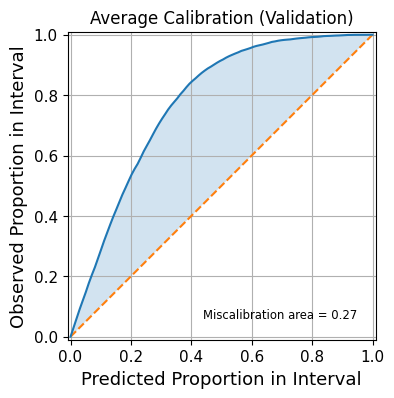

In [ ]:
uct.viz.plot_calibration(pred_val_mean.flatten(), pred_val_std.flatten(), target_val.flatten())
plt.gcf().set_size_inches(4, 4)
plt.title('Average Calibration (Validation)')
plt.grid()
plt.savefig('calibration_val_001_QM9.png', dpi=600, bbox_inches='tight')

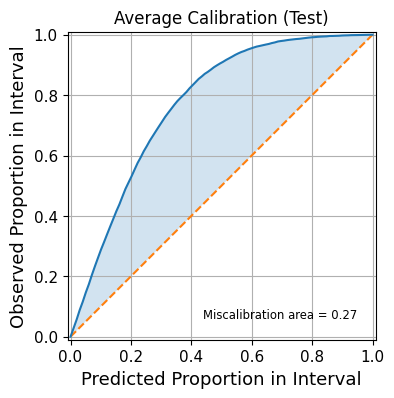

In [ ]:
uct.viz.plot_calibration(pred_test_mean.flatten(), pred_test_std.flatten(), target_test.flatten())
plt.gcf().set_size_inches(4, 4)
plt.title('Average Calibration (Test)')
plt.grid()
plt.savefig('calibration_test_001_QM9.png', dpi=600, bbox_inches='tight')

In [ ]:
pnn_metrics = uct.metrics.get_all_metrics(pred_test_mean.flatten(), pred_test_std.flatten(), target_test.flatten())

 (1/n) Calculating accuracy metrics
 (2/n) Calculating average calibration metrics
 (3/n) Calculating adversarial group calibration metrics
  [1/2] for mean absolute calibration error
Measuring adversarial group calibration by spanning group size between 0.0 and 1.0, in 10 intervals


100%|██████████| 10/10 [00:04<00:00,  2.27it/s]


  [2/2] for root mean squared calibration error
Measuring adversarial group calibration by spanning group size between 0.0 and 1.0, in 10 intervals


100%|██████████| 10/10 [00:05<00:00,  1.92it/s]


 (4/n) Calculating sharpness metrics
 (n/n) Calculating proper scoring rule metrics
**Finished Calculating All Metrics**


===================== Accuracy Metrics =====================
  MAE           0.920
  RMSE          1.249
  MDAE          0.722
  MARPD         0.081
  R2            1.000
  Correlation   1.000
=============== Average Calibration Metrics ================
  Root-mean-squared Calibration Error   0.300
  Mean-absolute Calibration Error       0.268
  Miscalibration Area                   0.270
========== Adversarial Group Calibration Metrics ===========
  Mean-absolute Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.275
     Group Size: 0.56 -- Calibration Error: 0.270
     Group Size: 1.00 -- Calibration Error: 0.268
  Root-mean-squared Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.307
     Group Size: 0.56 -- Calibration Error: 0.302
     Group Size: 1.00 -- Calibration Error: 0.300
================

##Isotonic Regression Post hoc calibration

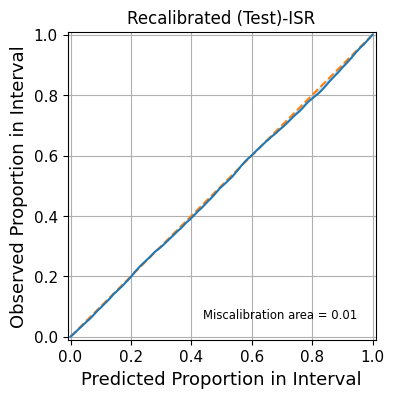

In [ ]:
recal_pred_mean = pred_val_mean.flatten()
recal_pred_std = pred_val_std.flatten()
recal_y = target_val.flatten()
exp_props, obs_props = uct.metrics_calibration.get_proportion_lists_vectorized(
    recal_pred_mean, recal_pred_std, recal_y,
)

# Train a recalibration model.
recal_model = uct.recalibration.iso_recal(exp_props, obs_props)

# Get the expected props and observed props using the new recalibrated model
te_recal_exp_props, te_recal_obs_props = uct.metrics_calibration.get_proportion_lists_vectorized(
    pred_test_mean.flatten(), pred_test_std.flatten(), target_test.flatten(), recal_model=recal_model
)

# Show the updated average calibration plot
uct.viz.plot_calibration(pred_test_mean.flatten(), pred_test_std.flatten(), target_test.flatten(),
                         exp_props=te_recal_exp_props,
                         obs_props=te_recal_obs_props)

plt.gcf().set_size_inches(4, 4)
plt.title('Recalibrated (Test)-ISR')
plt.grid()
plt.savefig('Recalibrated_Test_QM9_DE.png', dpi=600, bbox_inches='tight')

In [ ]:
recal_bounds_1sig = uct.metrics_calibration.get_prediction_interval(
    pred_test_mean.flatten(), pred_test_std.flatten(), 0.6827, recal_model)

isr_std_1sig = (recal_bounds_1sig.upper - recal_bounds_1sig.lower) / 2.0

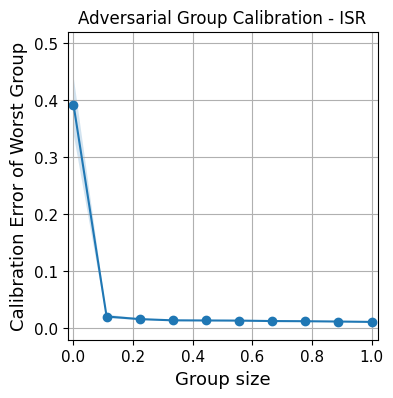

In [ ]:
uct.viz.plot_adversarial_group_calibration(pred_test_mean.flatten(), isr_std_1sig, target_test.flatten())
plt.gcf().set_size_inches(4, 4)
plt.grid()
plt.title('Adversarial Group Calibration - ISR')
plt.savefig('AGC_ISR_Reclibrated_DE.png', dpi=600, bbox_inches='tight')

In [ ]:
# Get all metrics
pnn_metrics = uct.metrics.get_all_metrics(pred_test_mean.flatten(), isr_std_1sig, target_test.flatten())

 (1/n) Calculating accuracy metrics
 (2/n) Calculating average calibration metrics
 (3/n) Calculating adversarial group calibration metrics
  [1/2] for mean absolute calibration error
Measuring adversarial group calibration by spanning group size between 0.0 and 1.0, in 10 intervals


100%|██████████| 10/10 [00:04<00:00,  2.24it/s]


  [2/2] for root mean squared calibration error
Measuring adversarial group calibration by spanning group size between 0.0 and 1.0, in 10 intervals


100%|██████████| 10/10 [00:04<00:00,  2.04it/s]


 (4/n) Calculating sharpness metrics
 (n/n) Calculating proper scoring rule metrics
**Finished Calculating All Metrics**


===================== Accuracy Metrics =====================
  MAE           0.920
  RMSE          1.249
  MDAE          0.722
  MARPD         0.081
  R2            1.000
  Correlation   1.000
=============== Average Calibration Metrics ================
  Root-mean-squared Calibration Error   0.015
  Mean-absolute Calibration Error       0.011
  Miscalibration Area                   0.011
========== Adversarial Group Calibration Metrics ===========
  Mean-absolute Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.019
     Group Size: 0.56 -- Calibration Error: 0.014
     Group Size: 1.00 -- Calibration Error: 0.011
  Root-mean-squared Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.026
     Group Size: 0.56 -- Calibration Error: 0.017
     Group Size: 1.00 -- Calibration Error: 0.015
================

##Standard Scaling post hoc calibration

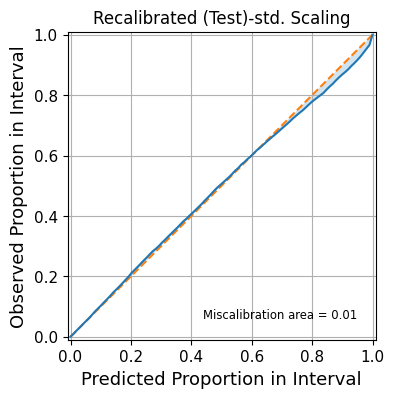

In [ ]:
std_scaling = uct.recalibration.optimize_recalibration_ratio(
      recal_pred_mean, recal_pred_std, recal_y, criterion="miscal"
)
new_pred_stds = std_scaling * pred_test_std.flatten()
 # Show the updated average calibration plot
uct.viz.plot_calibration(pred_test_mean.flatten(), new_pred_stds, target_test.flatten())
plt.gcf().set_size_inches(4, 4)
plt.title('Recalibrated (Test)-std. Scaling')
plt.grid()
plt.savefig('Recalibrated_test_QM9_std_scaling.png', dpi=600, bbox_inches='tight')

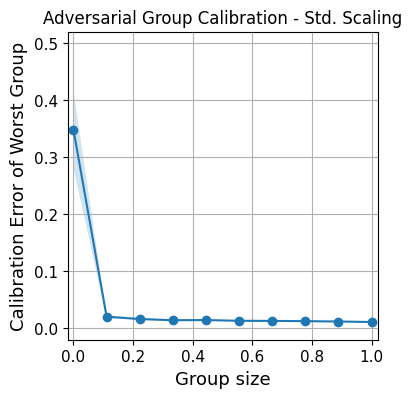

In [ ]:
uct.viz.plot_adversarial_group_calibration(pred_test_mean.flatten(), std_scaling * pred_test_std.flatten(), target_test.flatten())
plt.gcf().set_size_inches(4, 4)
plt.grid()
plt.title('Adversarial Group Calibration - Std. Scaling')
plt.savefig('AGC_SS_Reclibrated.png', dpi=600, bbox_inches='tight')
# plt.title('Recalibrated (Test)-ISR')

In [ ]:
# Get all metrics
pnn_metrics = uct.metrics.get_all_metrics(pred_test_mean.flatten(), std_scaling * pred_test_std.flatten(), target_test.flatten())

 (1/n) Calculating accuracy metrics
 (2/n) Calculating average calibration metrics
 (3/n) Calculating adversarial group calibration metrics
  [1/2] for mean absolute calibration error
Measuring adversarial group calibration by spanning group size between 0.0 and 1.0, in 10 intervals


100%|██████████| 10/10 [00:05<00:00,  1.94it/s]


  [2/2] for root mean squared calibration error
Measuring adversarial group calibration by spanning group size between 0.0 and 1.0, in 10 intervals


100%|██████████| 10/10 [00:04<00:00,  2.36it/s]


 (4/n) Calculating sharpness metrics
 (n/n) Calculating proper scoring rule metrics
**Finished Calculating All Metrics**


===================== Accuracy Metrics =====================
  MAE           0.920
  RMSE          1.249
  MDAE          0.722
  MARPD         0.081
  R2            1.000
  Correlation   1.000
=============== Average Calibration Metrics ================
  Root-mean-squared Calibration Error   0.015
  Mean-absolute Calibration Error       0.011
  Miscalibration Area                   0.011
========== Adversarial Group Calibration Metrics ===========
  Mean-absolute Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.021
     Group Size: 0.56 -- Calibration Error: 0.013
     Group Size: 1.00 -- Calibration Error: 0.011
  Root-mean-squared Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.023
     Group Size: 0.56 -- Calibration Error: 0.017
     Group Size: 1.00 -- Calibration Error: 0.015
================

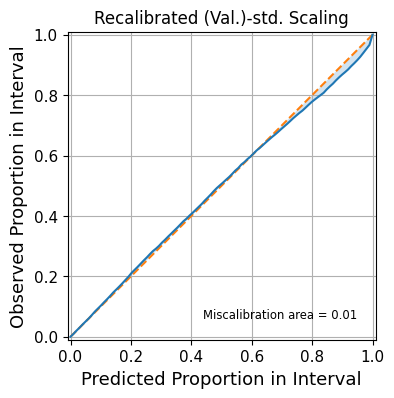

In [ ]:
uct.viz.plot_calibration(pred_test_mean.flatten(), std_scaling * pred_test_std.flatten(), target_test.flatten())
plt.gcf().set_size_inches(4, 4)
plt.title('Recalibrated (Val.)-std. Scaling')
plt.grid()
plt.savefig('Recalibrated_val_QM9_std_scaling.png', dpi=600, bbox_inches='tight')

##GPNormal Post hoc calibration

In [ ]:
from torch.utils.tensorboard import SummaryWriter
from netcal import manual_seed, cumulative_moments
from netcal.regression import IsotonicRegression, VarianceScaling, GPBeta, GPNormal, GPCauchy
from netcal.metrics import NLL, ENCE, UCE, QCE, PinballLoss
from netcal.presentation import ReliabilityRegression
from examples.regression.artificial import generate_variance_dependent, generate_mean_dependent, draw_distributions

manual_seed(0)

bins = 20  # used for evaluation metrics
quantiles = np.linspace(0.05, 0.95, 19)  # quantile levels, used for evaluation metrics
n_epochs = 200  # optimization epochs
use_cuda = False  # or: "cuda:0", "cuda:1", etc.
# initialize tensorboard logging
tensorboard = SummaryWriter("logs/netcal/regression/artificial")
reliability = ReliabilityRegression(quantiles=bins+1)
figures = []

  0%|          | 0/50 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/gpytorch/lazy/triangular_lazy_tensor.py:124: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2253.)
  res = torch.triangular_solve(right_tensor, self.evaluate(), upper=self.upper).solution
Loss: 1.6022: 100%|██████████| 50/50 [03:02<00:00,  3.64s/it]


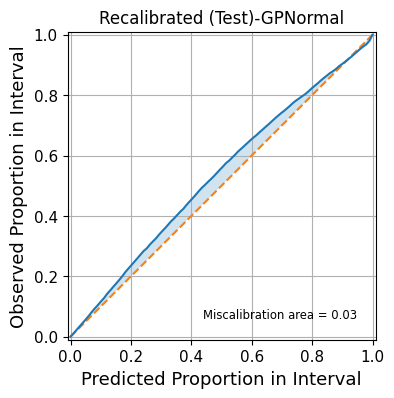

In [ ]:
gpnormal = GPNormal(n_inducing_points=50, n_random_samples=256, n_epochs=50, use_cuda=use_cuda)
gpnormal.fit((pred_val_mean.reshape(-1, 1), pred_val_std.reshape(-1, 1)), target_val.reshape(-1, 1), tensorboard=tensorboard)
ystd_gpnormal = gpnormal.transform((pred_test_mean, pred_test_std))

# squeeze calibrated stddev
ymean_gpnormal = pred_test_mean
# ystd_gpnormal = ystd_gpnormal[..., 0]

uct.viz.plot_calibration(ymean_gpnormal.ravel(), ystd_gpnormal.ravel(), target_test.ravel())
plt.gcf().set_size_inches(4, 4)
plt.title('Recalibrated (Test)-GPNormal')
plt.grid()
plt.savefig('Recalibrated_test_QM9_GPNormal.png', dpi=600, bbox_inches='tight')

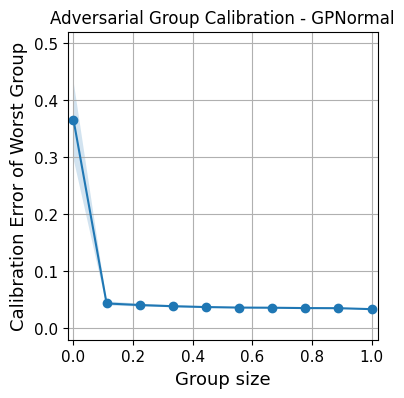

In [ ]:
uct.viz.plot_adversarial_group_calibration(pred_test_mean.flatten(), ystd_gpnormal.ravel(), target_test.flatten())
plt.gcf().set_size_inches(4, 4)
plt.grid()
plt.title('Adversarial Group Calibration - GPNormal')
plt.savefig('AGC_GPNormal_Reclibrated.png', dpi=600, bbox_inches='tight')

In [ ]:
# Get all metrics
pnn_metrics = uct.metrics.get_all_metrics(pred_test_mean.flatten(), ystd_gpnormal.ravel(), target_test.flatten())

 (1/n) Calculating accuracy metrics
 (2/n) Calculating average calibration metrics
 (3/n) Calculating adversarial group calibration metrics
  [1/2] for mean absolute calibration error
Measuring adversarial group calibration by spanning group size between 0.0 and 1.0, in 10 intervals


100%|██████████| 10/10 [00:05<00:00,  1.84it/s]


  [2/2] for root mean squared calibration error
Measuring adversarial group calibration by spanning group size between 0.0 and 1.0, in 10 intervals


100%|██████████| 10/10 [00:04<00:00,  2.04it/s]


 (4/n) Calculating sharpness metrics
 (n/n) Calculating proper scoring rule metrics
**Finished Calculating All Metrics**


===================== Accuracy Metrics =====================
  MAE           0.920
  RMSE          1.249
  MDAE          0.722
  MARPD         0.081
  R2            1.000
  Correlation   1.000
=============== Average Calibration Metrics ================
  Root-mean-squared Calibration Error   0.039
  Mean-absolute Calibration Error       0.034
  Miscalibration Area                   0.034
========== Adversarial Group Calibration Metrics ===========
  Mean-absolute Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.044
     Group Size: 0.56 -- Calibration Error: 0.037
     Group Size: 1.00 -- Calibration Error: 0.034
  Root-mean-squared Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.052
     Group Size: 0.56 -- Calibration Error: 0.042
     Group Size: 1.00 -- Calibration Error: 0.039
================

In [ ]:
indices = np.where(2 * pred_test_std < 2)[0]
print('Low uncertainty samples:', indices.shape)

large_diff_indices = np.where(np.abs(pred_test_mean.ravel()[indices] - target_test.ravel()[indices]) > 1)[0]
print("Number of false positives with |prediction - true value| > 1:", large_diff_indices.shape[0])

Low uncertainty samples: (3,)
Number of false positives with |prediction - true value| > 1: 0


In [ ]:
recal_bounds_2sig = uct.metrics_calibration.get_prediction_interval(
    pred_test_mean.flatten(), pred_test_std.flatten(), 0.9545, recal_model)

isr_std_2sig = (recal_bounds_2sig.upper - recal_bounds_2sig.lower) / 2.0

In [ ]:
threshold = 1
tolerance = 0

indices = np.where(isr_std_2sig + tolerance < threshold)[0]

# Find the points classified as "false positives" based on your tolerance and criterion
false_indices = np.where(np.abs(pred_test_mean.ravel()[indices] - target_test.ravel()[indices]) > tolerance + 1 * (isr_std_2sig.ravel()[indices]))[0]
print('Uncertain Samples:', indices.shape[0])

large_diff_indices = np.where(np.abs(pred_test_mean.ravel()[indices] - target_test.ravel()[indices]) > 1)[0]
print("Number of false positives with |prediction - true value| > 1:", large_diff_indices.shape[0])

Uncertain Samples: 31
Number of false positives with |prediction - true value| > 1: 11


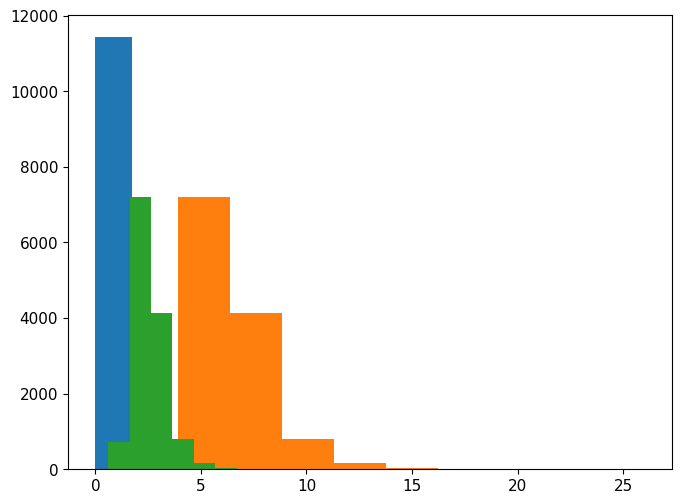

In [ ]:
plt.hist(np.abs(pred_test_mean.ravel() - target_test.ravel()))
plt.hist(2 * pred_test_std.flatten())
plt.hist(isr_std_2sig)
plt.show()

In [ ]:
# Plot settings
import matplotlib.pyplot as plt
import matplotlib as mpl
# import seaborn as sns

%matplotlib inline

mpl.rcParams['figure.figsize'] = [7.8,5.9]
mpl.rcParams['axes.labelsize'] = 13
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 15

# plt.style.use('seaborn-white')
# sns.set(color_codes=False)

legend_settings = {'loc':'upper center', 'ncol':3, 'frameon':True, 'facecolor':'white',
                   'framealpha':0.8, 'bbox_to_anchor':(0.5, 1.11)}

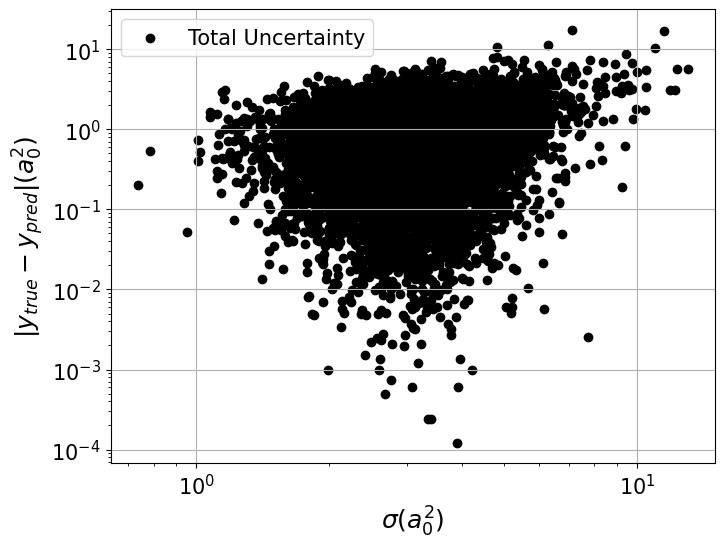

In [ ]:
plt.scatter(y=np.abs(target_test - pred_test_mean), x=pred_test_std, c='k', label='Total Uncertainty')
# plt.scatter(y=np.abs(targets_test_001 - pred_test_001), x=data_test_001['std_ep'], c='g', label='Epistemic Uncertainty')
# plt.scatter(y=np.abs(targets_test_001 - pred_test_001),x=data_test_001['std_al'], c='r', label='Aleatoric Uncertainty')
plt.grid()
plt.ylabel('$|y_{true} - y_{pred}| (a_{0}^2)$', fontsize=18)
plt.xlabel('$\sigma (a_{0}^2)$', fontsize=18)
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.savefig('Uncertainty_estimates_QM9_DE.png', dpi=600, bbox_inches='tight')
# plt.show()

##DER data

In [ ]:
data_val_001  = np.load('DER_QM9_val_0.01.npz')
data_test_001 = np.load('DER_QM9_test_0.01.npz')

In [ ]:
pred_val_001 = data_val_001['preds']
targets_val_001 = data_val_001['targets']
std_val_001 = data_val_001['std']
pred_test_001 = data_test_001['preds']
targets_test_001 = data_test_001['targets']
std_test_001 = data_test_001['std']

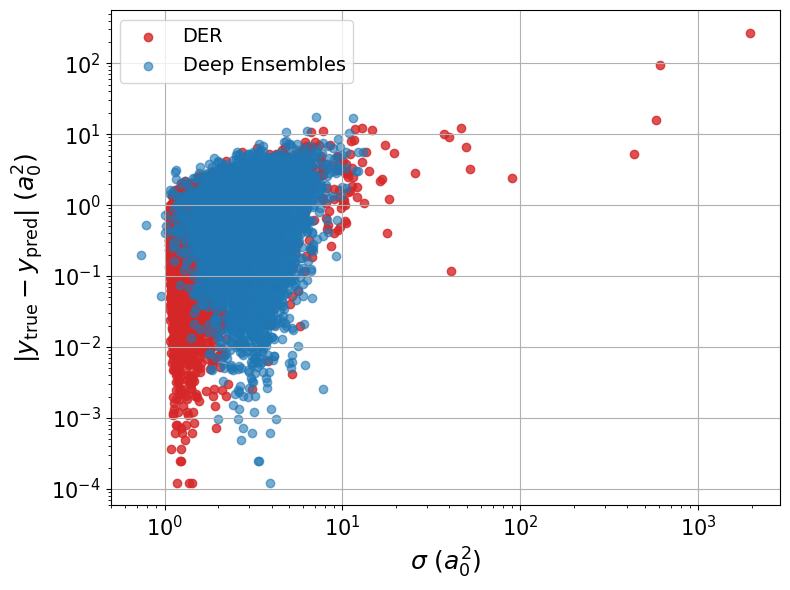

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Improved color and alpha settings
plt.scatter(y=np.abs(targets_test_001 - pred_test_001),
            x=data_test_001['std'],
            c='tab:red', alpha=0.8, label='DER')

plt.scatter(y=np.abs(target_test - pred_test_mean),
            x=pred_test_std,
            c='tab:blue', alpha=0.6, label='Deep Ensembles')

# Optional: uncomment if you want to add these
# plt.scatter(y=np.abs(targets_test_001 - pred_test_001),
#             x=data_test_001['std_ep'],
#             c='tab:green', alpha=0.6, label='Epistemic Uncertainty')
#
# plt.scatter(y=np.abs(targets_test_001 - pred_test_001),
#             x=data_test_001['std_al'],
#             c='tab:purple', alpha=0.6, label='Aleatoric Uncertainty')

plt.grid()
plt.ylabel(r'$|y_{\mathrm{true}} - y_{\mathrm{pred}}|$ ($a_0^2$)', fontsize=18)
plt.xlabel(r'$\sigma$ ($a_0^2$)', fontsize=18)
plt.legend(fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.savefig('Uncertainty_estimates_QM9_Comaprison.png', dpi=600, bbox_inches='tight')
# plt.show()
